# Exercício:

## 01 – Importe o .csv utilizado no exercício 1 da aula 13 e instancie um objeto da classe DataFrame. Busque no GenBank do NCBI, a sequência aminoacídica referente à cada gene, baixe o arquivo FASTA, e importe para o Python. Instancie um objeto da classe DataFrame onde as linhas serão os genes e as colunas, a sigla, o código de referência e a sequência aminoacídica.

In [1]:
import pandas as pd
import numpy as np
from Bio import Entrez
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_genes = pd.read_csv("df_genes.csv")
df_genes = df_genes.T
df_genes


,0,1,2,3
Heat shock protein 70,21,He,1,False
histone H2B,11,hi,0,False
cytochrome c oxidase subunit 1,30,cy,1,False
actin,5,ac,1,False
18S ribosomal RNA,17,18,2,False


In [38]:
import pandas as pd
from Bio import SeqIO
import io


df_original = pd.read_csv('df_genes.csv')
lista_genes = df_original.columns.tolist() # 


arquivos_fasta = {
    "Heat shock protein 70": "hsp70.txt", # 
    "histone H2B": "h2b.txt",             # 
    "cytochrome c oxidase subunit 1": "COX.txt", # 
    "actin": "actb.txt" #
}

dados_finais = []

for gene in lista_genes:
    if gene in arquivos_fasta:
       
        with open(arquivos_fasta[gene], "r") as f:
            record = SeqIO.read(f, "fasta")
            
            
            dados_finais.append({
                "Gene": gene,
                "Sigla": record.name.split('|')[-1].split('_')[0], 
                "Código de Referência": record.id,
                "Sequência Aminoacídica": str(record.seq)
            })
    else:
       
        dados_finais.append({
            "Gene": gene,
            "Sigla": None,
            "Código de Referência": None,
            "Sequência Aminoacídica": None
        })


df_amino = pd.DataFrame(dados_finais)
df_amino.set_index("Gene", inplace=True)


df_amino

,Sigla,Código de Referência,Sequência Aminoacídica
Gene,,,
Heat shock protein 70,M11717.1,lcl|M11717.1_prot_AAA52697.1_1,MAKAAAVGIDLGTTYSCVGVFQHGKVEIIANDQGNRTTPSYVAFTD...
histone H2B,AJ223353.1,lcl|AJ223353.1_prot_CAA11277.1_1,MPEPTKSAPAPKKGSKKAVTKAQKKDGKKRKRSRKESYSVYVYKVL...
cytochrome c oxidase subunit 1,U41284.1,lcl|U41284.1_prot_AAB19185.1_1,MASRLLRGAGTLAAQALRARGPSGAAAMRSMASGGTR
actin,PQ040393.1,lcl|PQ040393.1_prot_XCZ58824.1_1,MDDDIAALVVDNGSGMCKAGFAGDDAPRAVFPSIVGRPRHQGVMVG...
18S ribosomal RNA,NaN,NaN,NaN


Aqui o último gene não pode ter uma sequência de aminoácidos por ser um RNA de subunidade ribossômica

## 02 – Importe o .csv as informações dos aminoácidos e instancie um objeto da classe DataFrame. Obtenha a frequência absoluta de cada um dos aminoácidos para cada um dos genes. Instancie um objeto da classe DataFrame com as informações.

In [39]:
import pandas as pd
from collections import Counter


aminoacidos_padrao = list("ACDEFGHIKLMNPQRSTVWY")


def contar_residuos(sequencia):
    if pd.isna(sequencia):
        return {aa: 0 for aa in aminoacidos_padrao}
    contagem = Counter(sequencia)
    return {aa: contagem.get(aa, 0) for aa in aminoacidos_padrao}


lista_frequencias = [contar_residuos(seq) for seq in df_amino['Sequência Aminoacídica']]


df_frequencia_final = pd.DataFrame(lista_frequencias, index=df_amino.index)


print("--- Tabela de Frequência Absoluta de Aminoácidos ---")
display(df_frequencia_final)

--- Tabela de Frequência Absoluta de Aminoácidos ---


,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
Gene,,,,,,,,,,,,,,,,,,,,
Heat shock protein 70,56,5,45,47,25,56,7,41,50,50,9,30,24,27,30,34,41,46,2,15
histone H2B,12,0,3,7,2,7,3,6,20,6,3,3,6,3,8,14,9,9,0,5
cytochrome c oxidase subunit 1,10,0,0,0,0,6,0,0,0,4,3,0,1,1,6,4,2,0,0,0
actin,29,6,23,26,13,28,9,28,19,27,17,9,19,12,18,25,26,22,4,15
18S ribosomal RNA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 03 – Qual é o número de Valinas presentes em cada um dos genes? Qual o gene tem o maior número?

In [ ]:

valinas = df_frequencia_final['V']
maior_gene = valinas.idxmax()

print(f"Valinas por gene:\n{valinas}")
print(f"O gene com mais valinas é: {maior_gene} ({valinas.max()})")

Valinas por gene:
Gene
Heat shock protein 70             46
histone H2B                        9
cytochrome c oxidase subunit 1     0
actin                             22
18S ribosomal RNA                  0
Name: V, dtype: int64
O gene com mais valinas é: Heat shock protein 70 (46)


## 04 – Qual a média, a mediana e a moda da frequência absoluta de Serina presente nos genes?

In [40]:

serinas = df_frequencia_final['S']

media = serinas.mean()
mediana = serinas.median()
moda = serinas.mode()[0] 

print(f"Média de Serina: {media}")
print(f"Mediana de Serina: {mediana}")
print(f"Moda de Serina: {moda}")

Média de Serina: 15.4
Mediana de Serina: 14.0
Moda de Serina: 0


## 05 – Gere um histograma, contendo a média e a mediana, com o número de Serinas por gene.

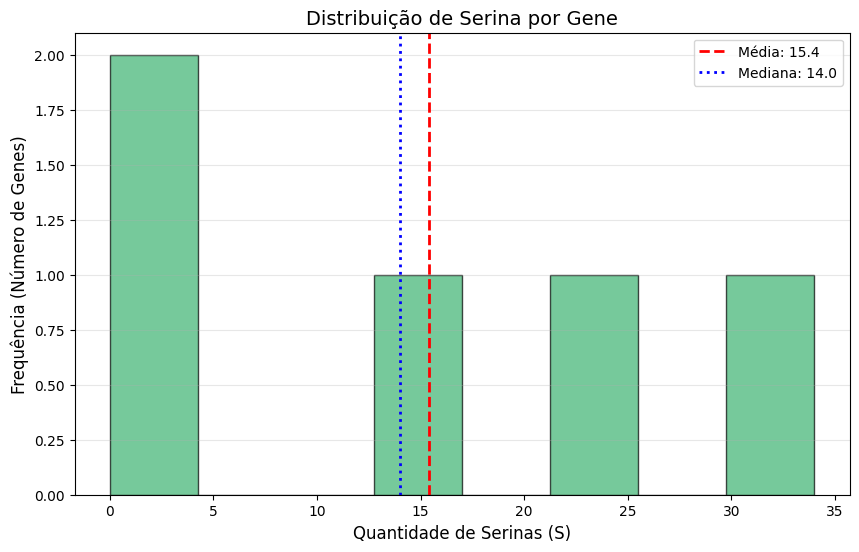

In [41]:
import matplotlib.pyplot as plt


serinas = df_frequencia_final['S']
media = serinas.mean()
mediana = serinas.median()


plt.figure(figsize=(10, 6))


n, bins, patches = plt.hist(serinas, bins=8, color='mediumseagreen', edgecolor='black', alpha=0.7)


plt.axvline(media, color='red', linestyle='dashed', linewidth=2, label=f'Média: {media:.1f}')


plt.axvline(mediana, color='blue', linestyle='dotted', linewidth=2, label=f'Mediana: {mediana:.1f}')


plt.title('Distribuição de Serina por Gene', fontsize=14)
plt.xlabel('Quantidade de Serinas (S)', fontsize=12)
plt.ylabel('Frequência (Número de Genes)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

## 06 – Defina uma função que receba o nome de um aa qualquer e retorne o mesmo resultado do exercício anterior.

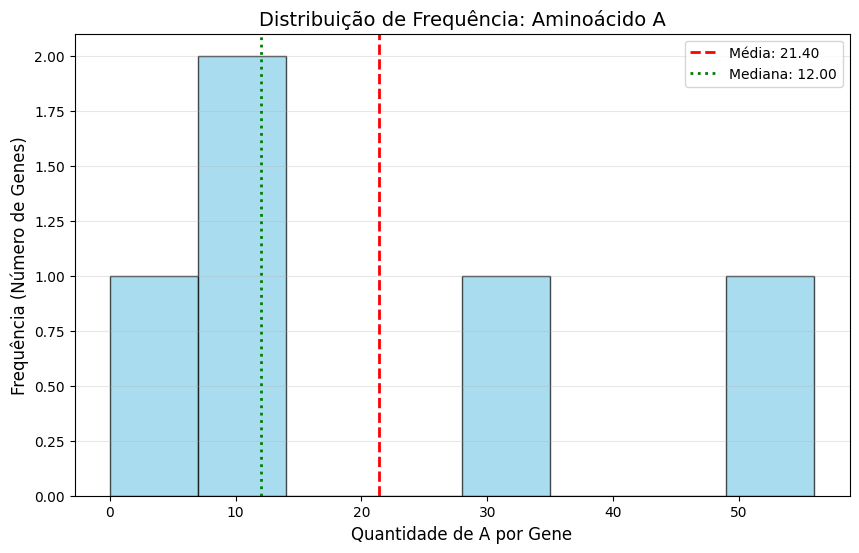

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

def analisar_aminoacido(sigla_aa, df_frequencia):
    """
    Recebe a sigla de um aminoácido (ex: 'S', 'V', 'A') e o DataFrame de frequências.
    Gera um histograma com média e mediana.
    """
   
    sigla_aa = sigla_aa.upper()
    
    if sigla_aa not in df_frequencia.columns:
        print(f"Erro: O aminoácido '{sigla_aa}' não foi encontrado no DataFrame.")
        return

    
    dados = df_frequencia[sigla_aa]
    media = dados.mean()
    mediana = dados.median()

    
    plt.figure(figsize=(10, 6))
    
    
    plt.hist(dados, bins=8, color='skyblue', edgecolor='black', alpha=0.7)
    
    
    plt.axvline(media, color='red', linestyle='dashed', linewidth=2, label=f'Média: {media:.2f}')
    plt.axvline(mediana, color='green', linestyle='dotted', linewidth=2, label=f'Mediana: {mediana:.2f}')
    
    
    plt.title(f'Distribuição de Frequência: Aminoácido {sigla_aa}', fontsize=14)
    plt.xlabel(f'Quantidade de {sigla_aa} por Gene', fontsize=12)
    plt.ylabel('Frequência (Número de Genes)', fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    
    plt.show()


analisar_aminoacido('A', df_frequencia_final)

## 07 – Retorne os gráficos dos aa Glutamina, Glicina, Lisina e Valina. Qual possuí menor diferença entre média e mediana?

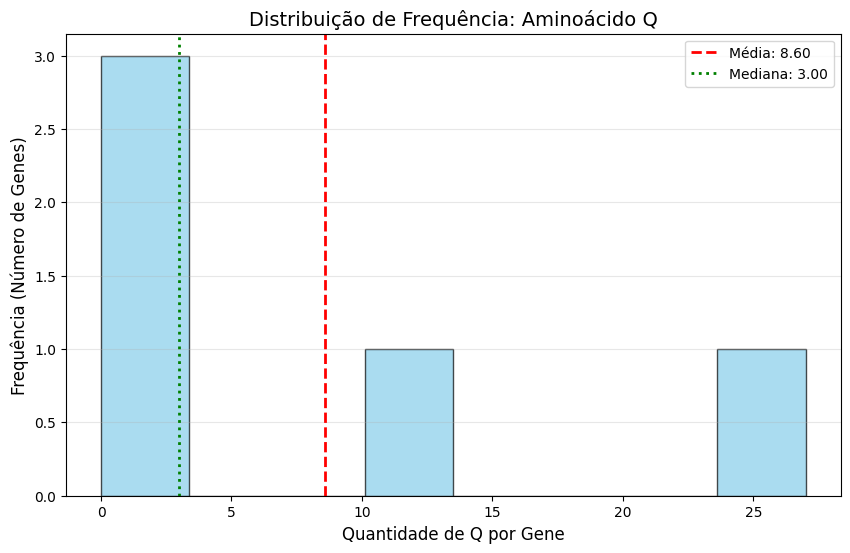

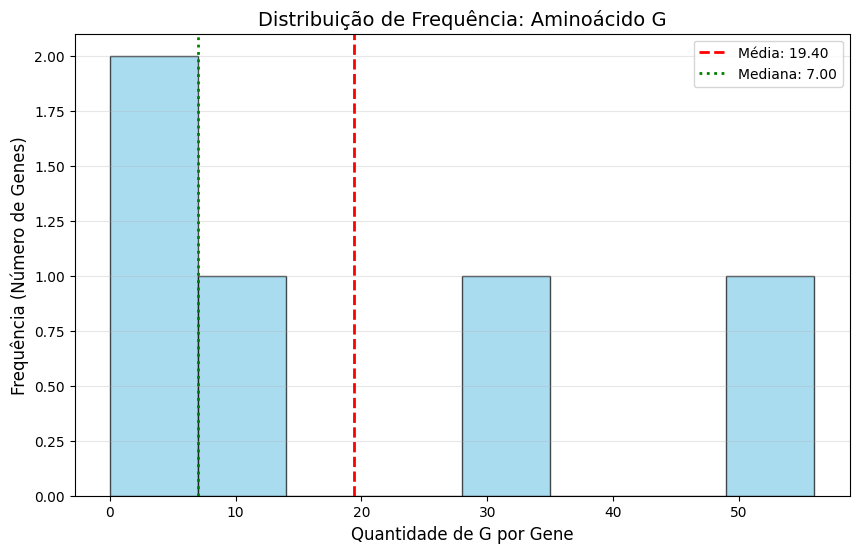

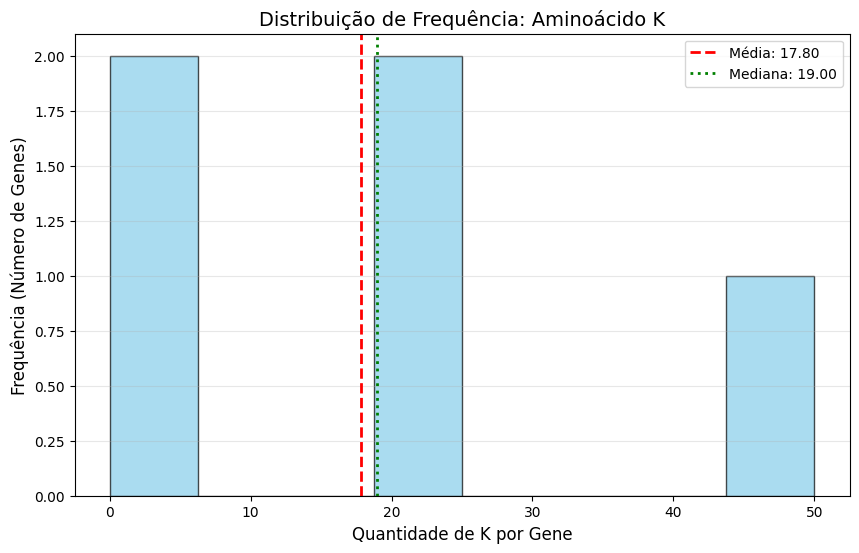

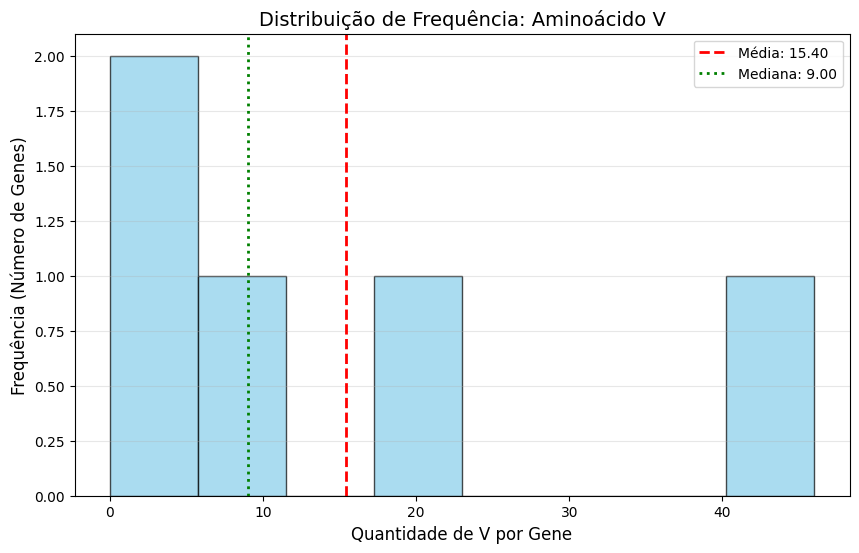

In [43]:

aminoacidos_alvo = ['Q', 'G', 'K', 'V']

for aa in aminoacidos_alvo:
    analisar_aminoacido(aa, df_frequencia_final)

## 08 – Dentre os três primeiros genes, qual é a média e a mediana de Cisteína?

In [ ]:

cisteinas_top3 = df_frequencia_final.iloc[:3]['C']

print(f"Média: {cisteinas_top3.mean():.2f}")
print(f"Mediana: {cisteinas_top3.median()}")

Média: 1.67
Mediana: 0.0


## 09 – Analisando o valor médio de aa em cada um dos genes, qual seria o maior gene (maior número médio de aa)?

In [46]:

medias_por_gene = df_frequencia_final.iloc[:, :20].mean(axis=1)

print(medias_por_gene.sort_values(ascending=False))

#o maior gene é o "heat shock protein 70

Gene
Heat shock protein 70             32.00
actin                             18.75
histone H2B                        6.30
cytochrome c oxidase subunit 1     1.85
18S ribosomal RNA                  0.00
dtype: float64


## 10 – Olhando o valor médio de aa em cada um dos genes, qual seria o menor gene (menor número médio de aa)?

In [ ]:
# Calcula a média das colunas de aminoácidos (as primeiras 20 colunas)
medias_por_gene = df_frequencia_final.iloc[:, :20].mean(axis=1)

print(medias_por_gene.sort_values(ascending=False))

#o menor gene é o "cytochrome c oxidase"

Gene
Heat shock protein 70             32.00
actin                             18.75
histone H2B                        6.30
cytochrome c oxidase subunit 1     1.85
18S ribosomal RNA                  0.00
dtype: float64


In [47]:
# Exportando o DataFrame de frequências (criado no exercício anterior) para CSV
df_frequencia_final.to_csv('frequencia_aminoacidos.csv', index=True)